# Convergencia

## Analisis

En este libro probaremos y graficaremos la convergencia de los modelos para ver como se van comportando. De esta forma veremos como se comporta con diferentes dataSet y con ayuda de este entorno grafico podremos entender mejor que está sucediendo.

In [15]:
#Primero de todo importamos las librerías necesarias para el proyecto

#Librerias para la creacion de los modelos
import tensorflow as tf
from tensorflow import keras
import sklearn
from keras import layers
from sklearn.preprocessing import MinMaxScaler

#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 

#Libreria para dibujar graficos
import matplotlib.pyplot as plt


In [16]:
#Ahora importamos nuestra capa creada que vamos a analizar en este proyecto siendo la que tiene el polinomio de Lagrange

class PolynomialDense2(tf.keras.layers.Layer):
    def __init__(self, units, degree=2, use_bias=True, **kwargs):
        super(PolynomialDense2, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # El kernel debe cubrir (grado + 1) si incluyes P0, o (grado) si empiezas en P1
        # Aquí usaremos desde P1 hasta P_degree
        self.kernel = self.add_weight(
            shape=(input_dim * self.degree, self.units),
            initializer=tf.keras.initializers.GlorotUniform(),
            trainable=True,
            name="kernel"
        )

        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True,
                name="bias"
            )

    def call(self, inputs):
        # Aseguramos que los inputs sean float32
        x = tf.cast(inputs, self.compute_dtype)
        
        # P0 = 1, P1 = x
        p_nm2 = tf.ones_like(x)
        p_nm1 = x
        
        features = [p_nm1] # Empezamos con grado 1

        for n in range(2, self.degree + 1):
            n_float = tf.cast(n, self.compute_dtype)
            # Fórmula de recurrencia de Legendre
            p_n = ((2.0 * n_float - 1.0) * x * p_nm1 - (n_float - 1.0) * p_nm2) / n_float
            features.append(p_n)
            
            p_nm2 = p_nm1
            p_nm1 = p_n

        # Concatenamos: (batch, input_dim * degree)
        # Esto genera: [x_poly1, x_poly2, ..., x_poly_degree]
        phi = tf.concat(features, axis=-1)

        output = tf.matmul(phi, self.kernel)

        if self.use_bias:
            output = tf.nn.bias_add(output, self.bias)

        return output

In [17]:
#Ahora debemos debemos de crear una función para dibujar la grafica de entrenamiento
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida de validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    
    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión de validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
#Cargamos los datos del Dataset.
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 


#Separamos el dataset en entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normalizamos los datos para que el entrenamiento sea más eficiente entre -1 y 1
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train.shape[1]


#Cambiamos las etiquetas a 0 y 1
y_train = (y_train == 'g').astype(int)
y_test = (y_test == 'g').astype(int)

10 10


In [ ]:
"""
#Modelo polinómico grado 2

inputPoli = keras.Input(shape=(input_dim,))
x2 = PolynomialDense2(32, degree=2)(inputPoli)
x2 = layers.Activation('swish')(x2)
x2 = layers.Dense(16, activation='swish')(x2)
outputPoli2 = layers.Dense(2, activation='softmax')(x2)

#Modelo polinómico grado 3
inputPoli3 = keras.Input(shape=(input_dim,))
x3 = PolynomialDense2(32, degree=3)(inputPoli3)
x3 = layers.Activation('swish')(x3)
x3 = layers.Dense(16, activation='swish')(x3)
outputPoli3 = layers.Dense(2, activation='softmax')(x3)

#Modelo polinómico grado 4
inputPoli4 = keras.Input(shape=(input_dim,))
x4 = PolynomialDense2(32, degree=4)(inputPoli4)
x4 = layers.Activation('swish')(x4)
x4 = layers.Dense(16, activation='swish')(x4)
outputPoli4 = layers.Dense(2, activation='softmax')(x4)
"""

In [6]:
"""
# Definimos el Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         # Vigila el error en los datos que el modelo NO conoce
    patience=15,                # Si en 15 épocas no mejora el val_loss, se detiene
    verbose=1,                  # Nos avisa en consola cuando se detenga
    restore_best_weights=True   # ¡VITAL! Al terminar, vuelve a los pesos de la época 100
)
"""

"\n# Definimos el Early Stopping\nearly_stopping = tf.keras.callbacks.EarlyStopping(\n    monitor='val_loss',         # Vigila el error en los datos que el modelo NO conoce\n    patience=15,                # Si en 15 épocas no mejora el val_loss, se detiene\n    verbose=1,                  # Nos avisa en consola cuando se detenga\n    restore_best_weights=True   # ¡VITAL! Al terminar, vuelve a los pesos de la época 100\n)\n"

In [ ]:
"""
#Creamos los modelos

model_poli2 = keras.Model(inputs=inputPoli, outputs=outputPoli2, name="Polynomial_Model_Degree_2")
model_poli3 = keras.Model(inputs=inputPoli3, outputs=outputPoli3, name="Polynomial_Model_Degree_3")
model_poli4 = keras.Model(inputs=inputPoli4, outputs=outputPoli4, name="Polynomial_Model_Degree_4")

#Compilamos los modelos

model_poli2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_poli3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_poli4.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
"""

In [19]:
epochs = 120
batch_size = 32

In [20]:
def PolynomialDenseCreator(degree):
    inputPoli = keras.Input(shape=(input_dim,))
    x = PolynomialDense2(32, degree=degree)(inputPoli)
    x = layers.Activation('swish')(x)
    x = layers.Dense(16, activation='swish')(x)
    outputPoli = layers.Dense(2, activation='softmax')(x)
    model = keras.Model(inputs=inputPoli, outputs=outputPoli, name=f"Polynomial_Model_Degree_{degree}")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
"""
history_poli2 = model_poli2.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)
history_poli3 = model_poli3.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)
history_poli4 = model_poli4.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)
"""

Epoch 1/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7980 - loss: 0.4554 - val_accuracy: 0.8318 - val_loss: 0.4155
Epoch 2/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8368 - loss: 0.3878 - val_accuracy: 0.8288 - val_loss: 0.3877
Epoch 3/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8422 - loss: 0.3745 - val_accuracy: 0.8377 - val_loss: 0.3790
Epoch 4/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8438 - loss: 0.3686 - val_accuracy: 0.8440 - val_loss: 0.3720
Epoch 5/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8503 - loss: 0.3631 - val_accuracy: 0.8413 - val_loss: 0.3713
Epoch 6/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8526 - loss: 0.3600 - val_accuracy: 0.8443 - val_loss: 0.3746
Epoch 7/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8514 - loss: 0.3562 - val_accuracy: 0.8449 - val_loss: 0.3632
Epoch 8/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8521 - loss: 0.3539 - val_accu

In [21]:
#importamos para ir borrando el historial de entrenamiento y así evitar que se sobreescriba el mismo historial en cada modelo
from keras import backend as K

# --- Entrenamiento Grado 2 ---
K.clear_session()  # Limpiamos la sesión para evitar que los modelos compartan pesos o historial
print("Entrenando Grado 2...")
model_poli2 = PolynomialDenseCreator(degree=2)
history_poli2 = model_poli2.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)

# --- Entrenamiento Grado 3 ---
# Lo ideal es re-instanciarlo justo aquí:
print("Entrenando Grado 3...")
K.clear_session()  # Limpiamos la sesión para evitar que los modelos compartan pesos o historial
model_poli3 = PolynomialDenseCreator(degree=3)
history_poli3 = model_poli3.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)

# --- Entrenamiento Grado 4 ---
print("Entrenando Grado 4...")
K.clear_session()  # Limpiamos la sesión para evitar que los modelos compartan pesos o historial
model_poli4 = PolynomialDenseCreator(degree=4)
history_poli4 = model_poli4.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)


Entrenando Grado 2...
Epoch 1/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7854 - loss: 0.4655 - val_accuracy: 0.8308 - val_loss: 0.4105
Epoch 2/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8367 - loss: 0.3882 - val_accuracy: 0.8338 - val_loss: 0.3865
Epoch 3/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8405 - loss: 0.3744 - val_accuracy: 0.8417 - val_loss: 0.3765
Epoch 4/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8453 - loss: 0.3661 - val_accuracy: 0.8476 - val_loss: 0.3711
Epoch 5/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8484 - loss: 0.3598 - val_accuracy: 0.8482 - val_loss: 0.3619
Epoch 6/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8495 - loss: 0.3567 - val_accuracy: 0.8479 - val_loss: 0.3558
Epoch 7/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8529 - loss: 0.3523 - val_accuracy: 0.8479 - val_loss: 0.3570
Epoch 8/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8535 - l

Gráfica de convergencia para el modelo polinómico de grado 2 con accuracy: 0.87513


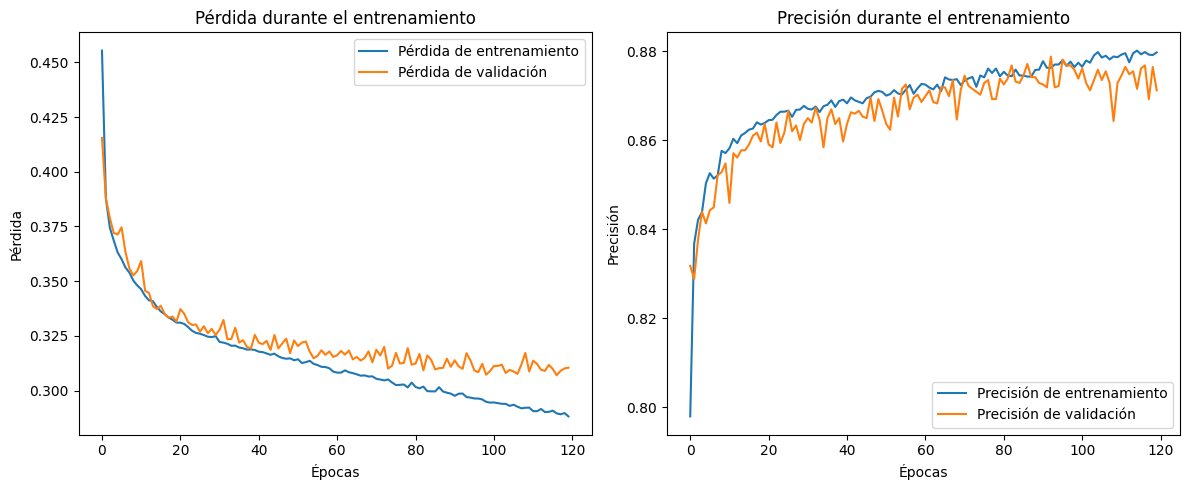

Gráfica de convergencia para el modelo polinómico de grado 3 con accuracy: 0.87986


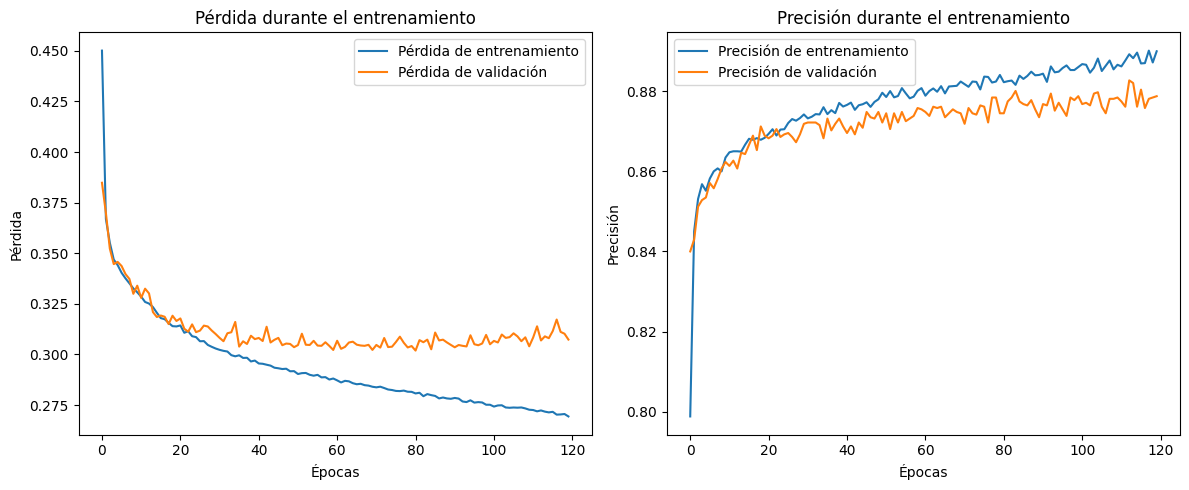

Gráfica de convergencia para el modelo polinómico de grado 4 con accuracy: 0.87776


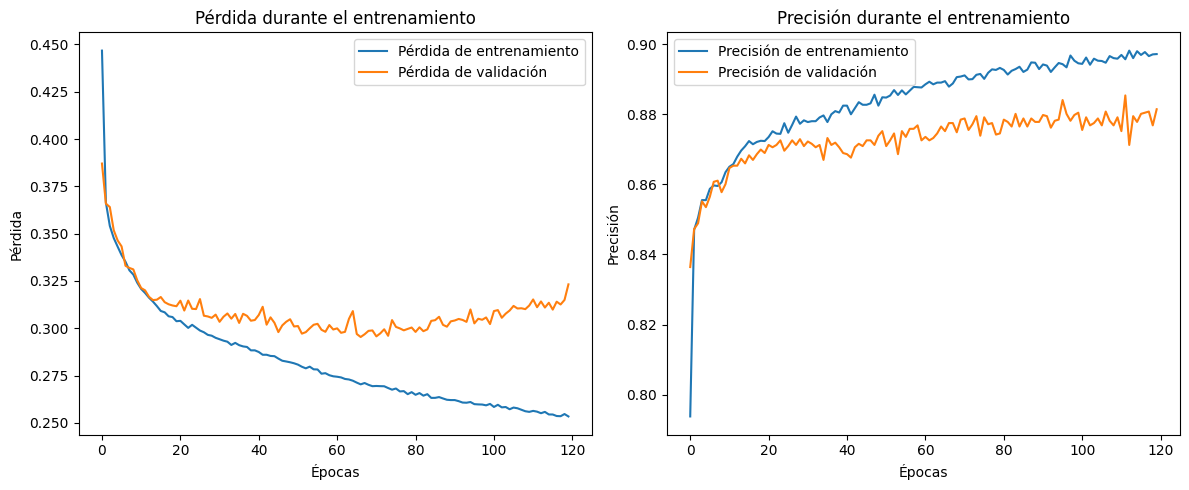

In [13]:
#Dibujamos las gráficas de convergencia para cada modelo u debajo el acurracy obtenido en el test

print("Gráfica de convergencia para el modelo polinómico de grado 2 con accuracy: {:.5f}".format(model_poli2.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history_poli2)
print("Gráfica de convergencia para el modelo polinómico de grado 3 con accuracy: {:.5f}".format(model_poli3.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history_poli3)
print("Gráfica de convergencia para el modelo polinómico de grado 4 con accuracy: {:.5f}".format(model_poli4.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history_poli4)


Gráfica de convergencia para el modelo polinómico de grado 2 con accuracy: 0.87907


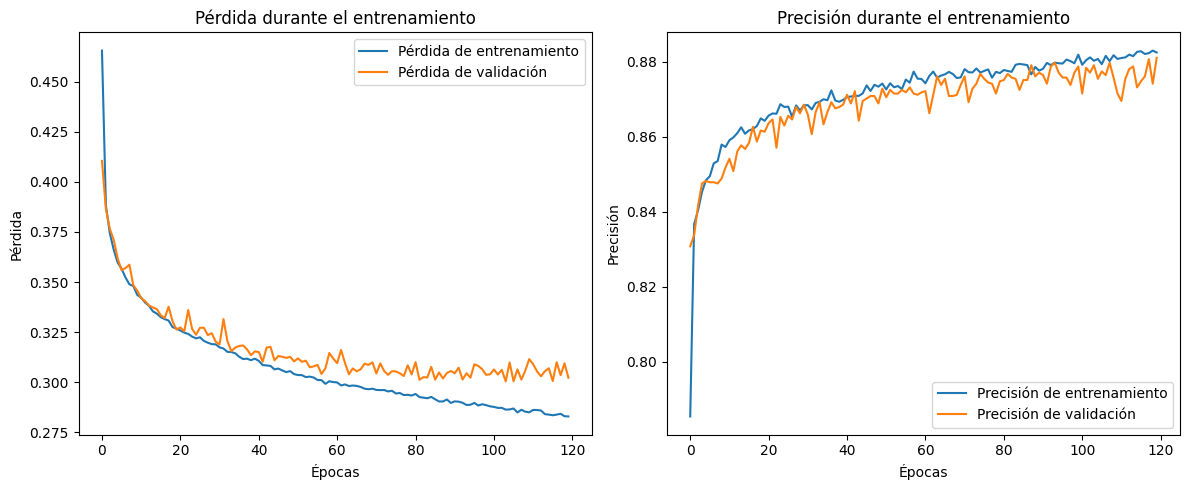

Gráfica de convergencia para el modelo polinómico de grado 3 con accuracy: 0.88013


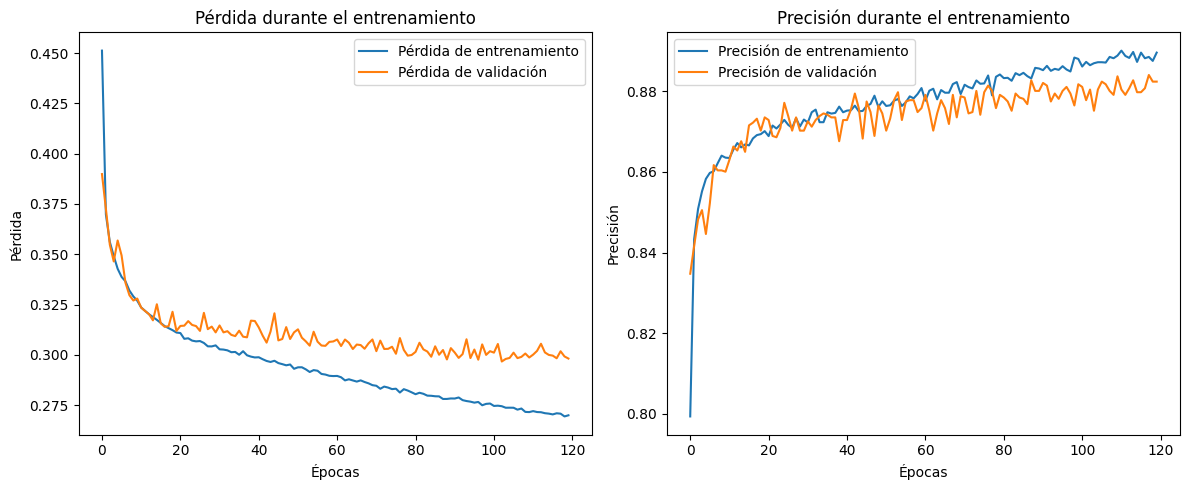

Gráfica de convergencia para el modelo polinómico de grado 4 con accuracy: 0.87986


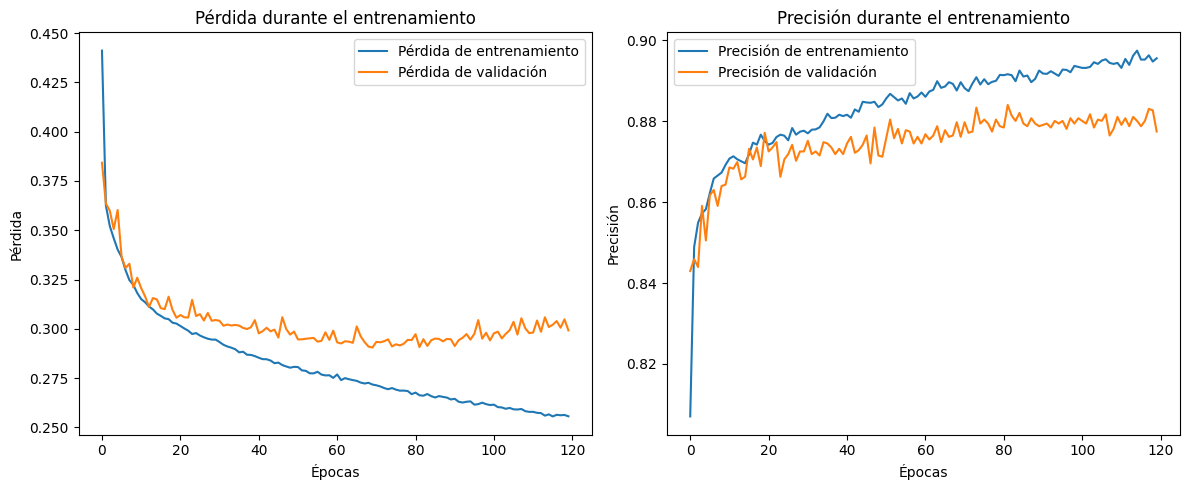

In [22]:
#Dibujamos las gráficas de convergencia para cada modelo u debajo el acurracy obtenido en el test

print("Gráfica de convergencia para el modelo polinómico de grado 2 con accuracy: {:.5f}".format(model_poli2.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history_poli2)
print("Gráfica de convergencia para el modelo polinómico de grado 3 con accuracy: {:.5f}".format(model_poli3.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history_poli3)
print("Gráfica de convergencia para el modelo polinómico de grado 4 con accuracy: {:.5f}".format(model_poli4.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history_poli4)


## Analizamos para una sola ejecución

In [ ]:
#Primero de todo importamos las librerías necesarias para el proyecto

#Librerias para la creacion de los modelos
import tensorflow as tf
from tensorflow import keras
import sklearn
from keras import layers
from sklearn.preprocessing import MinMaxScaler

#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 

#Libreria para dibujar graficos
import matplotlib.pyplot as plt


In [18]:

#Ahora importamos nuestra capa creada que vamos a analizar en este proyecto siendo la que tiene el polinomio de Lagrange

class PolynomialDense2(tf.keras.layers.Layer):
    def __init__(self, units, degree=2, use_bias=True, **kwargs):
        super(PolynomialDense2, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # El kernel debe cubrir (grado + 1) si incluyes P0, o (grado) si empiezas en P1
        # Aquí usaremos desde P1 hasta P_degree
        self.kernel = self.add_weight(
            shape=(input_dim * self.degree, self.units),
            initializer=tf.keras.initializers.GlorotUniform(),
            trainable=True,
            name="kernel"
        )

        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True,
                name="bias"
            )

    def call(self, inputs):
        # Aseguramos que los inputs sean float32
        x = tf.cast(inputs, self.compute_dtype)
        
        # P0 = 1, P1 = x
        p_nm2 = tf.ones_like(x)
        p_nm1 = x
        
        features = [p_nm1] # Empezamos con grado 1

        for n in range(2, self.degree + 1):
            n_float = tf.cast(n, self.compute_dtype)
            # Fórmula de recurrencia de Legendre
            p_n = ((2.0 * n_float - 1.0) * x * p_nm1 - (n_float - 1.0) * p_nm2) / n_float
            features.append(p_n)
            
            p_nm2 = p_nm1
            p_nm1 = p_n

        # Concatenamos: (batch, input_dim * degree)
        # Esto genera: [x_poly1, x_poly2, ..., x_poly_degree]
        phi = tf.concat(features, axis=-1)

        output = tf.matmul(phi, self.kernel)

        if self.use_bias:
            output = tf.nn.bias_add(output, self.bias)

        return output
    


In [19]:
#Ahora debemos debemos de crear una función para dibujar la grafica de entrenamiento
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
    plt.plot(history.history['val_loss'], label='Pérdida de validación')
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    
    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Precisión de validación')
    plt.title('Precisión durante el entrenamiento')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    


In [20]:
#Cargamos los datos del Dataset.
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 


#Separamos el dataset en entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normalizamos los datos para que el entrenamiento sea más eficiente entre -1 y 1
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train.shape[1]


#Cambiamos las etiquetas a 0 y 1
y_train = (y_train == 'g').astype(int)
y_test = (y_test == 'g').astype(int)


In [21]:
def PolynomialDenseCreator(degree):
    inputPoli = keras.Input(shape=(input_dim,))
    x = PolynomialDense2(32, degree=degree)(inputPoli)
    x = layers.Activation('swish')(x)
    x = layers.Dense(16, activation='swish')(x)
    outputPoli = layers.Dense(2, activation='softmax')(x)
    model = keras.Model(inputs=inputPoli, outputs=outputPoli, name=f"Polynomial_Model_Degree_{degree}")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [22]:
#Parametros para el entrenamiento
degree = 7
epochs = 120


In [23]:
#importamos para ir borrando el historial de entrenamiento y así evitar que se sobreescriba el mismo historial en cada modelo
from keras import backend as K

# --- Entrenamiento Grado 2 ---
K.clear_session()  # Limpiamos la sesión para evitar que los modelos compartan pesos o historial
print("Entrenando Grado" + str(degree) + " ...")
modeloTest = PolynomialDenseCreator(degree)
history = modeloTest.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32)


Entrenando Grado7 ...
Epoch 1/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8118 - loss: 0.4263 - val_accuracy: 0.8407 - val_loss: 0.3717
Epoch 2/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8526 - loss: 0.3540 - val_accuracy: 0.8558 - val_loss: 0.3484
Epoch 3/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8577 - loss: 0.3391 - val_accuracy: 0.8604 - val_loss: 0.3371
Epoch 4/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8621 - loss: 0.3324 - val_accuracy: 0.8617 - val_loss: 0.3341
Epoch 5/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8649 - loss: 0.3274 - val_accuracy: 0.8637 - val_loss: 0.3281
Epoch 6/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8666 - loss: 0.3217 - val_accuracy: 0.8607 - val_loss: 0.3314
Epoch 7/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8681 - loss: 0.3199 - val_accuracy: 0.8666 - val_loss: 0.3251
Epoch 8/120
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8698 - l


RESULTADOS FINALES (Grado 7)
Acurracy en test: 0.87671


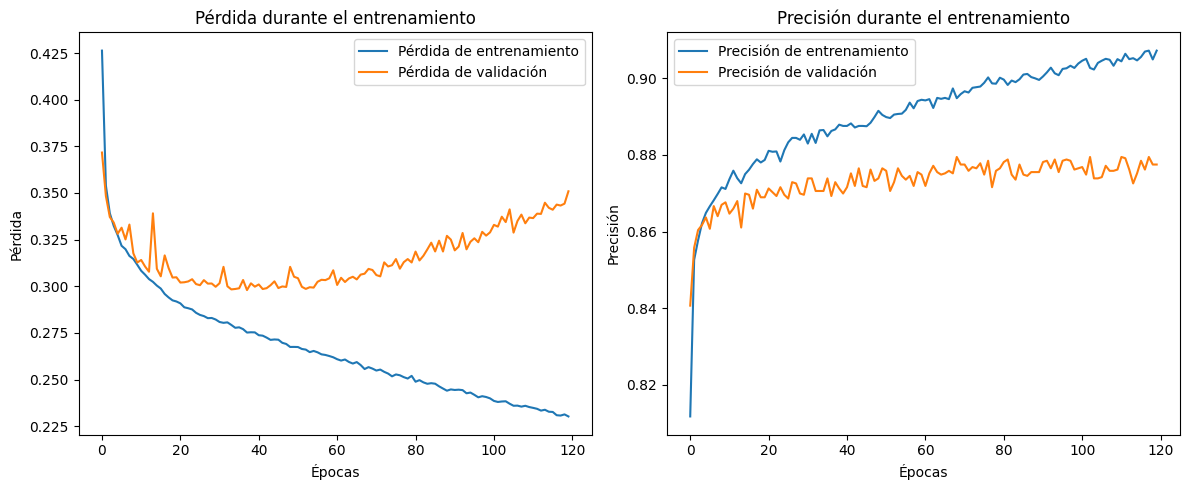

In [24]:
print("\n" + "="*40)
print(f"RESULTADOS FINALES (Grado {degree})")
print("Acurracy en test: {:.5f}".format(modeloTest.evaluate(X_test_scaled, y_test, verbose=0)[1]))
plot_training_history(history)